# ML LAB-4
# Name: Sneha Kanjwani
# CMS ID: 023-24-0273
# Section: H
# GitHub: https://github.com/snehakanjwani30/ML-telco-customer-churn-eda
# Kaggle: https://www.kaggle.com/snehakanjwani
# Dataset: Telco Customer Churn (cleaned in Lab 2)
# Dataset Source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Part 1 — Decision Tree Baseline Review

In [4]:
#TASK-1
import pandas as pd
df = pd.read_csv('clean_churn.csv')
print('Dataset shape:',df.shape)
df.head()
#Interpretation: The cleaned Telco Customer Churn dataset was successfully loaded. The dataset contains 7,021 rows and 20 columns. 
#The first few rows show the customer information and the `Churn` column that will be used as the target variable.

Dataset shape: (7021, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])
X = pd.get_dummies(X, drop_first=True, dtype=int)
print("X shape:", X.shape)
print("y shape:", y.shape)
#Interpretation: The Churn column was converted into 0 and 1 so it can be used by the model. The other columns 
# were converted into numerical features using one-hot encoding. After preprocessing, there are 30 features that can be used to predict customer churn.

X shape: (7021, 30)
y shape: (7021,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
#Interpretation: The data was divided into training and testing sets, with 80% used for training and 20% for testing. 
# Stratification was used to keep the proportion of churn and non-churn customers similar in both sets.

X_train shape: (5616, 30)
X_test shape: (1405, 30)
y_train shape: (5616,)
y_test shape: (1405,)


In [10]:
#TASK-2
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
dt_model.fit(X_train, y_train)
y_dt_pred = dt_model.predict(X_test)
#Interpretation: A Decision Tree model was trained using a maximum depth of 5. The model was then used to predict 
# whether customers in the test set would churn or not.

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_accuracy = accuracy_score(y_test, y_dt_pred)
dt_precision = precision_score(y_test, y_dt_pred)
dt_recall = recall_score(y_test, y_dt_pred)
dt_f1 = f1_score(y_test, y_dt_pred)
print("Baseline Decision Tree Results")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-score :", dt_f1)
#Interpretation: The Decision Tree achieved an accuracy of about 78.7% and an F1-score of about 51.2%. 
# The model performed reasonably well, but its recall was lower, meaning it missed some customers who actually churned.

Baseline Decision Tree Results
Accuracy : 0.7871886120996441
Precision: 0.6514522821576764
Recall   : 0.4220430107526882
F1-score : 0.5122349102773246


### Baseline Interpretation

The Decision Tree with a maximum depth of 5 achieved an accuracy of approximately 78.72%, precision of 65.15%, recall of 42.20%, and F1-score of 51.22% on the test set. This model is used as the benchmark for the rest of Lab 4. New ensemble models will be compared with these results to determine whether they provide better performance, especially for identifying customers who are likely to churn.


# Part 2 — Random Forest

In [12]:
#TASK-3
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42
)
rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)
#Interpretation: A Random Forest model was trained using 200 decision trees. The model was then used to predict customer churn on the test data.

In [ ]:
#TASK-4
#A Random Forest combines predictions from many Decision Trees instead of
#depending on one tree. This reduces overfitting and usually makes the model 
#more stable and better at generalizing to unseen data.

# Part 3 — Evaluation & Comparison

In [13]:
#TASK-5
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(y_test, y_rf_pred)
rf_precision = precision_score(y_test, y_rf_pred)
rf_recall = recall_score(y_test, y_rf_pred)
rf_f1 = f1_score(y_test, y_rf_pred)
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1-score:", rf_f1)
#Interpretation: The Random Forest achieved about 77.4% accuracy and an F1-score of about 50.2%. 
# Its recall was slightly better than the Decision Tree, but its overall performance was a little lower.

Random Forest Accuracy: 0.7743772241992882
Random Forest Precision: 0.6037735849056604
Random Forest Recall: 0.43010752688172044
Random Forest F1-score: 0.5023547880690737


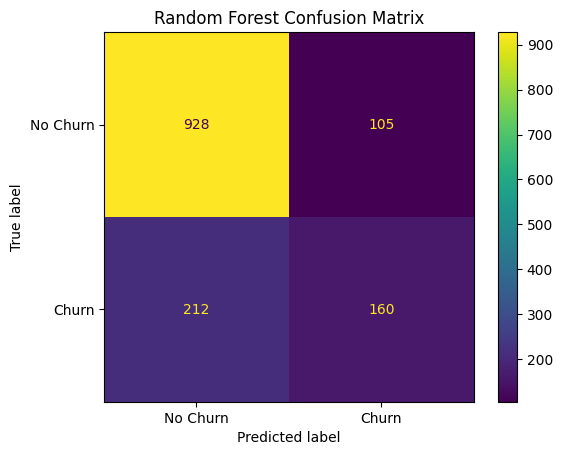

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()
#Interpretation: The confusion matrix shows how well the Random Forest classified churn and non-churn customers. 
# It shows the number of correct and incorrect predictions for both classes, helping us see where the model is making mistakes.

In [12]:
#TASK-6
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall],
    "F1-score": [dt_f1, rf_f1]
})
comparison
#Interpretation: The table compares the Decision Tree and Random Forest using accuracy, precision, recall, and F1-score. 
# The Decision Tree has slightly higher accuracy, precision, and F1-score, while the Random Forest has slightly better recall.
# Overall, their performance is quite close, with the Decision Tree performing slightly better on most metrics.

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.787189,0.651452,0.422043,0.512235
1,Random Forest,0.774377,0.603774,0.430108,0.502355


# TASK-7
The Decision Tree performs slightly better overall than the Random Forest. It has higher accuracy, precision, and F1-score, while the Random Forest has slightly higher recall. The difference between the two models is marginal. Because the dataset is imbalanced, F1-score is the most important metric because it considers both precision and recall.

# Part 4 — Cross-Validation

In [13]:
#TASK-8
from sklearn.model_selection import cross_val_score
dt_cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring='f1')
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1')
print("Decision Tree F1 scores:", dt_cv_scores)
print("Random Forest F1 scores:", rf_cv_scores)
print("Decision Tree Mean F1:", dt_cv_scores.mean())
print("Decision Tree Std F1:", dt_cv_scores.std())
print("Random Forest Mean F1:", rf_cv_scores.mean())
print("Random Forest Std F1:", rf_cv_scores.std())
#Interpretation: The 5-fold cross-validation results show that the Random Forest has a higher mean F1-score than the Decision Tree, 
# which means it performs better when tested on different parts of the dataset. Its standard deviation is also lower, 
# showing that the Random Forest gives more consistent results across the five folds.

Decision Tree F1 scores: [0.57013575 0.46998285 0.48184818 0.51752922 0.53375196]
Random Forest F1 scores: [0.55023184 0.53354134 0.49924357 0.55538222 0.57446809]
Decision Tree Mean F1: 0.5146495912896955
Decision Tree Std F1: 0.036119126587306156
Random Forest Mean F1: 0.5425734103309466
Random Forest Std F1: 0.02529442861441777


# TASK-9
The cross-validation results show that Random Forest performs better than the Decision Tree on average. Random Forest has a mean F1-score of 0.54257, while the Decision Tree has a mean F1-score of 0.51465. Random Forest also has a lower standard deviation of 0.02529 compared to 0.03612 for the Decision Tree, which means its performance is more consistent across the five folds. The cross-validation results give a more reliable comparison because the models are tested on different parts of the dataset.

# Part 5 — Hyperparameter Tuning

In [15]:
#TASK-10
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring='f1'
)
grid_search.fit(X_train, y_train)
#Interpretation: Grid Search was used to test different Random Forest settings, including the number of trees, 
# maximum depth, and minimum samples required to split a node. Five-fold cross-validation with F1-score was used to 
# find the combination of settings that gives the best performance.

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

In [16]:
#TASK-11
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validated F1:", grid_search.best_score_)
#Interpretation: Grid Search found the best combination of Random Forest parameters based on the highest cross-validated F1-score. 
# The best settings were max_depth = 10, min_samples_split = 5, and n_estimators = 200, with a cross-validated F1-score of about 0.5762.

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validated F1: 0.5761800999818016


In [19]:
#TASK-12
tuned_rf = grid_search.best_estimator_

tuned_rf_predictions = tuned_rf.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
tuned_accuracy = accuracy_score(y_test, tuned_rf_predictions)
tuned_precision = precision_score(y_test, tuned_rf_predictions)
tuned_recall = recall_score(y_test, tuned_rf_predictions)
tuned_f1 = f1_score(y_test, tuned_rf_predictions)
print("Tuned Random Forest Accuracy:", tuned_accuracy)
print("Tuned Random Forest Precision:", tuned_precision)
print("Tuned Random Forest Recall:", tuned_recall)
print("Tuned Random Forest F1-score:", tuned_f1)
#Interpretation: The tuned Random Forest was tested on the held-out test data using accuracy, precision, recall, and F1-score. 
# After tuning, the model achieved about 79.8% accuracy and an F1-score of 56.3%, showing a clear improvement compared with the default Random Forest.

Tuned Random Forest Accuracy: 0.798576512455516
Tuned Random Forest Precision: 0.6606498194945848
Tuned Random Forest Recall: 0.49193548387096775
Tuned Random Forest F1-score: 0.5639445300462249


# Part 6 — Final Comparison & Feature Importance

In [20]:
#TASK-13
final_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Tuned Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy, tuned_accuracy],
    "Precision": [dt_precision, rf_precision, tuned_precision],
    "Recall": [dt_recall, rf_recall, tuned_recall],
    "F1-score": [dt_f1, rf_f1, tuned_f1]
})
final_comparison
#Interpretation: This table compares all three models using the same evaluation metrics. The Tuned Random Forest performs the best, with 
# the highest accuracy, precision, recall, and F1-score. This shows that tuning the Random Forest parameters improved its performance 
# compared with both the original Decision Tree and Random Forest.

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.787189,0.651452,0.422043,0.512235
1,Random Forest,0.774377,0.603774,0.430108,0.502355
2,Tuned Random Forest,0.798577,0.660650,0.491935,0.563945


# TASK-14
The Tuned Random Forest was selected as the final model because it performed better than both the Decision Tree and default Random Forest on the test set. It achieved the highest accuracy (0.79857), precision (0.66065), recall (0.49193), and F1-score (0.56394). The cross-validation results also showed a better mean F1-score for the tuned model, so it is the best overall choice.


In [21]:
importances = tuned_rf.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)
#Interpretation: The feature importance results show which features had the most influence on the Tuned Random Forest's predictions. 
# Features with higher importance values contributed more to the model's decision when predicting customer churn.

tenure                                   0.183362
TotalCharges                             0.167454
MonthlyCharges                           0.118583
InternetService_Fiber optic              0.075880
Contract_Two year                        0.058842
PaymentMethod_Electronic check           0.055729
OnlineSecurity_Yes                       0.034458
Contract_One year                        0.034027
TechSupport_Yes                          0.023534
PaperlessBilling_Yes                     0.020150
SeniorCitizen                            0.016053
MultipleLines_Yes                        0.015431
TechSupport_No internet service          0.015424
DeviceProtection_No internet service     0.014850
OnlineBackup_Yes                         0.014425
Dependents_Yes                           0.013898
Partner_Yes                              0.013436
gender_Male                              0.012624
StreamingMovies_No internet service      0.012252
StreamingMovies_Yes                      0.012208


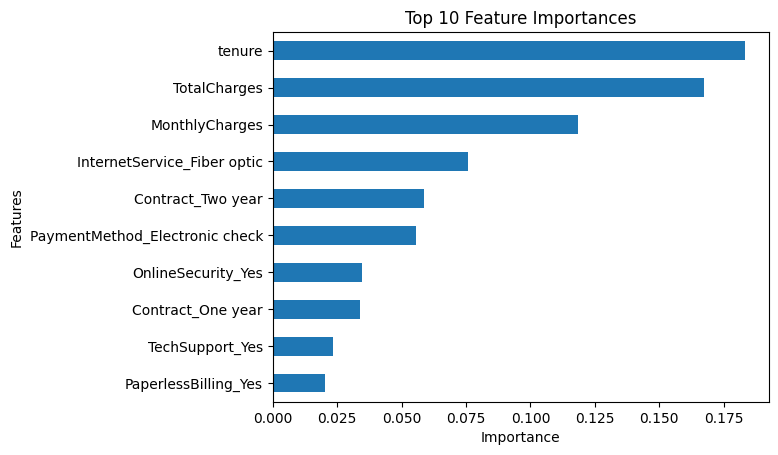

In [22]:
import matplotlib.pyplot as plt

feature_importance.head(10).sort_values().plot(kind='barh')

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances")
plt.show()
#Interpretation: The bar chart shows the top 10 features that were most important for the Tuned Random Forest's predictions. 
# Features with longer bars had a greater influence on the model's decision, while features with shorter bars had less influence.

# TASK-15
The top five important features in the tuned Random Forest are tenure, TotalCharges, MonthlyCharges, InternetService_Fiber optic, and Contract_Two year. The results are similar to the Decision Tree from Lab 3 because tenure, InternetService_Fiber optic, TotalCharges, and MonthlyCharges were also among the important features in that model. This also matches the EDA findings because customer tenure, monthly charges, total charges, and internet service are related to customer churn.


# Part 7 — Kaggle Submission & Conclusion

In [23]:
#TASK-16
predictions = tuned_rf.predict(X_test)
submission = pd.DataFrame({
    "CustomerIndex": X_test.index,
    "Churn": predictions
})
submission.to_csv("submission.csv", index=False)
submission.head()
#Interpretation: Since customerID was dropped during cleaning, the test set's row index was used as a stand-in customer identifier, 
# saved alongside the predicted Churn value in submission.csv

,CustomerIndex,Churn
0,5615,1
1,6112,0
2,2356,1
3,2196,0
4,832,0


In [22]:
submission.shape

(1405, 2)

# TASK-17
The Tuned Random Forest was selected as the final model because it performed better than both the Decision Tree and the default Random Forest. It achieved an accuracy of 0.7985 and an F1-score of 0.5639 on the held-out test set, compared with an F1-score of 0.5122 for the Lab 3 Decision Tree. Hyperparameter tuning improved the Random Forest's overall performance. However, the model still has limitations because the dataset is imbalanced and its recall is not very high. The model may also perform differently on new customer data that is different from the training data.


# TASK-18
If I had more time, I would try other algorithms such as XGBoost and Gradient Boosting and compare them with the Random Forest. I would also perform more hyperparameter tuning to find better model settings. Since the dataset is imbalanced, I would try class weights or oversampling to improve the model's ability to detect customers who churn. I would also test the final model on more data to make sure its performance is reliable.
